# Spring-mass chain illustration

The physical chain schematic + the banded $[A_\star\,|\,B_\star]$ sparsity pattern it
induces. Writes `spring_chain.{pdf,png}` into this notebook's folder.

In [1]:
import os, sys

# LaTeX on PATH for usetex (environment-specific; harmless if your TeX lives elsewhere).
tex_path = "/dss/dsshome1/07/go69lir/texlive/2026/bin/x86_64-linux"
if os.path.isdir(tex_path) and tex_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + tex_path

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow

from system_generator import sample_spring_chain

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}",
    "font.family": "serif", "font.size": 11, "savefig.bbox": "tight",
})

In [3]:
N = 6  # masses for the illustration
d, p = 2 * N, N // 2
A, B, supports, _ = sample_spring_chain(d=d, p=p, seed=0)
act = ((np.arange(p) * N) // p).tolist()


def spring(ax, x0, x1, y, coils=5, amp=0.13):
    """Draw a zig-zag spring between (x0, y) and (x1, y)."""
    lead = 0.18
    xs = np.linspace(x0 + lead, x1 - lead, 2 * coils + 1)
    ys = y + amp * np.array([0] + [(-1) ** k for k in range(2 * coils - 1)] + [0])
    ax.plot([x0, x0 + lead], [y, y], "k", lw=1.1)
    ax.plot(xs, ys, "k", lw=1.1)
    ax.plot([x1 - lead, x1], [y, y], "k", lw=1.1)

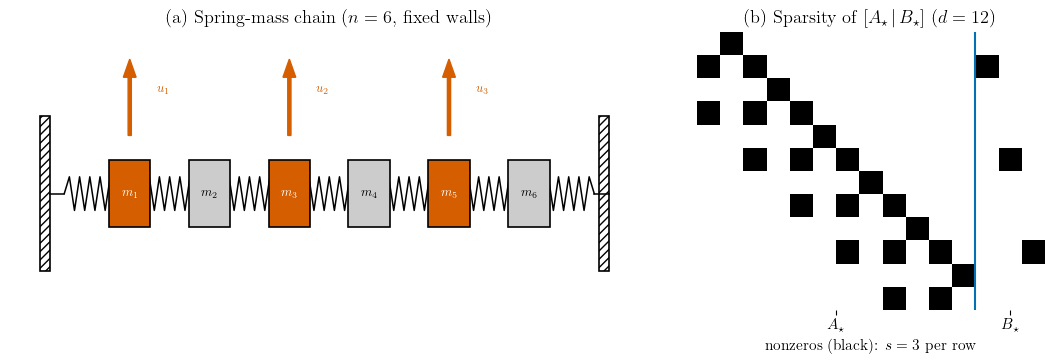

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6),
                               gridspec_kw={"width_ratios": [1.55, 1]})

# (a) physical chain
y = 0.0
for w in (0.0, N + 1.0):  # walls
    ax1.add_patch(Rectangle((w - 0.12, -0.6), 0.12, 1.2, hatch="////", fill=False, lw=1.2))
xs_mass = np.arange(1, N + 1)
spring(ax1, 0.0, 1.0, y)                        # left wall spring
for i in range(N - 1):
    spring(ax1, xs_mass[i], xs_mass[i + 1], y)  # inter-mass springs
spring(ax1, float(N), N + 1.0, y)               # right wall spring
for i, x in enumerate(xs_mass):
    actuated = i in act
    ax1.add_patch(Rectangle((x - 0.26, -0.26), 0.52, 0.52,
                            facecolor="#D55E00" if actuated else "#cccccc",
                            edgecolor="k", lw=1.2, zorder=3))
    ax1.text(x, 0, f"$m_{{{i+1}}}$", ha="center", va="center", zorder=4,
             color="white" if actuated else "black", fontsize=9)
    if actuated:
        ax1.add_patch(FancyArrow(x, 0.45, 0, 0.45, width=0.04, head_width=0.16,
                                 head_length=0.14, color="#D55E00", zorder=4))
        ax1.text(x + 0.34, 0.78, f"$u_{{{act.index(i)+1}}}$", color="#D55E00", fontsize=9)
ax1.set_xlim(-0.5, N + 1.5); ax1.set_ylim(-0.9, 1.25)
ax1.axis("off"); ax1.set_title("(a) Spring-mass chain ($n=6$, fixed walls)")

# (b) sparsity pattern of [A | B]
d, p = A.shape[0], B.shape[1]
mask = np.zeros((d, d + p))
mask[:, :d] = A != 0
mask[:, d:] = B != 0
ax2.imshow(mask, cmap="Greys", vmin=0, vmax=1, aspect="equal", interpolation="nearest")
ax2.axvline(d - 0.5, color="#0072B2", lw=1.5)  # A | B divider
ax2.set_xticks([d / 2 - 0.5, d + p / 2 - 0.5]); ax2.set_xticklabels(["$A_\star$", "$B_\star$"])
ax2.set_yticks([]); ax2.set_title("(b) Sparsity of $[A_\star\,|\,B_\star]$ ($d=12$)")
ax2.set_xlabel("nonzeros (black): $s=3$ per row")
for s in ax2.spines.values():
    s.set_visible(False)
fig.tight_layout()

wrote spring_chain.pdf | actuated masses: [1, 3, 5]


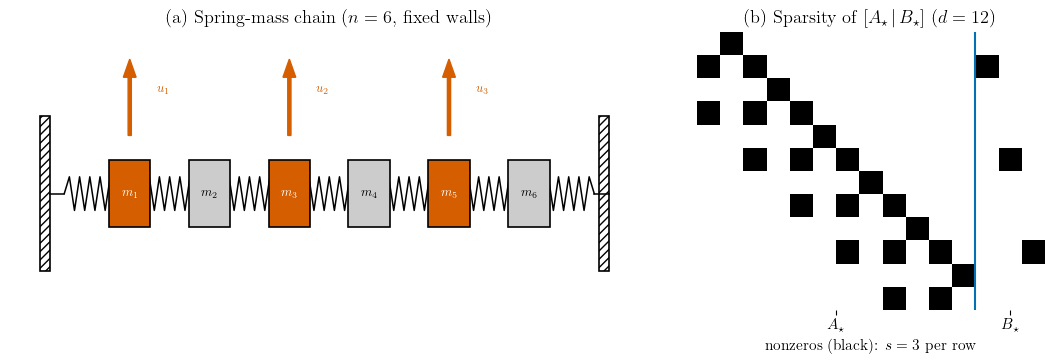

In [5]:
# saved into the notebook folder (cwd)
fig.savefig("spring_chain.pdf")
fig.savefig("spring_chain.png", dpi=150)
print("wrote spring_chain.pdf | actuated masses:", [a + 1 for a in act])
fig